### Experiment 7: Effect of Regularization

## Research Question

How does regularization affect the generalization performance of Linear
Regression, and how does the regularization strength influence model
performance?

## Hypothesis

Increasing regularization strength will reduce model complexity and
coefficient magnitude, thereby reducing overfitting. However, excessive
regularization is expected to cause underfitting and reduce predictive
performance.

Ridge, Lasso, and Elastic Net are expected to improve generalization
compared with unregularized Linear Regression when redundant or highly
correlated features are present.

## Why Are We Doing This After H6?

Experiment 6 showed that increasing model complexity improved training
performance but significantly reduced validation performance, indicating
overfitting.

Therefore, Experiment 7 investigates whether regularization can control
model complexity, reduce overfitting, and improve generalization.

The experiment follows this relationship:

Increasing Complexity
→ Better Training Fit
→ Overfitting
→ Regularization
→ Controlled Complexity
→ Improved Generalization

## Regularization Methods

### Ridge Regression

Ridge Regression uses L2 regularization to penalize large coefficients.

$$
J(\theta)
=
MSE
+
\lambda \sum_{j=1}^{p}\theta_j^2
$$

where:

- J(\theta) = regularized objective function
- \(MSE\) = mean squared error
- \(\lambda\) = regularization strength
- \(\theta_j\) = coefficient of the \(j^{th}\) feature
- \(p\) = total number of features

### Lasso Regression

Lasso Regression uses L1 regularization.

$$
J(\theta)
=
MSE
+
\lambda \sum_{j=1}^{p}|\theta_j|
$$

L1 regularization can shrink some coefficients exactly to zero,
allowing Lasso to perform feature selection.

### Elastic Net

Elastic Net combines L1 and L2 regularization.

$$
J(\theta)
=
MSE
+
\lambda
\left[
\alpha\sum_{j=1}^{p}|\theta_j|
+
(1-\alpha)\sum_{j=1}^{p}\theta_j^2
\right]
$$

where:

- \(\lambda\) = overall regularization strength
- \(\alpha\) = mixing parameter between L1 and L2 regularization
- \(\alpha=1\) corresponds to Lasso
- \(\alpha=0\) corresponds to Ridge

## Experimental Design

The regularization strength will be varied using different values of
\(\lambda\) (represented by `alpha` in scikit-learn):

$$
\lambda \in
\{0.001,\ 0.01,\ 0.1,\ 1,\ 10,\ 100,\ 1000\}
$$

The effect of regularization strength will be evaluated using:

- Training RMSE
- Validation RMSE
- Training MAE
- Validation MAE
- Training \(R^2\)
- Validation \(R^2\)
- Coefficient magnitude

The objective is to determine how increasing \(\lambda\) affects model
complexity, coefficient magnitude, and generalization performance.

As regularization strength increases:

$$
\lambda \uparrow
\quad\Rightarrow\quad
\text{Stronger penalty}
\quad\Rightarrow\quad
\text{Smaller coefficients}
$$

If regularization becomes excessive:

$$
\lambda \uparrow\uparrow
\quad\Rightarrow\quad
\text{Underfitting}
\quad\Rightarrow\quad
\text{Poorer validation performance}
$$

### Experiment 7A

In [41]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\HP\AppData\Local\Temp\ipykernel_12936\4013469833.py:1: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
X = df.drop(columns=["median_house_value"])
y =df['median_house_value']

In [6]:
from sklearn.model_selection import train_test_split

#Split the raw data inot train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [16]:
features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

X_train_subset = X_train[features]
X_val_subset = X_test[features]

In [18]:
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train_subset)
X_val_imputed = imputer.transform(X_val_subset)

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

In [27]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=0.1),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=1000)
}

In [30]:
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    # Evaluation Metrics
    train_rmse = root_mean_squared_error(y_train, y_train_pred) 

    val_rmse = root_mean_squared_error(y_test, y_val_pred)

    train_mae = mean_absolute_error(
        y_train,
        y_train_pred
    )

    val_mae = mean_absolute_error(
        y_test,
        y_val_pred
    )

    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    val_r2 = r2_score(
        y_test,
        y_val_pred
    )

    results.append({
        "Model": name,
        "Train_RMSE": train_rmse,
        "Validation_RMSE": val_rmse,
        "Train_MAE": train_mae,
        "Validation_MAE": val_mae,
        "Train_R2": train_r2,
        "Validation_R2": val_r2
    })

results_7A = pd.DataFrame(results)

results_7A

,Model,Train_RMSE,Validation_RMSE,Train_MAE,Validation_MAE,Train_R2,Validation_R2
0,LinearRegression,69389.154322,70858.656956,50773.476720,51298.989683,0.635618,0.633822
1,Ridge,69389.154391,70858.500370,50773.444296,51298.869974,0.635618,0.633823
2,Lasso,69389.154327,70858.615403,50773.491464,51298.971269,0.635618,0.633822
3,ElasticNet,71104.034914,71830.587475,52215.597539,52374.778151,0.617385,0.623707


### Experiment 7B: Regularization Strength

In [31]:
alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

### Ridge

In [36]:
ridge_results = []

for alpha in alphas:

    model = Ridge(alpha=alpha)

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    ridge_results.append({
        "Alpha": alpha,
        "Train_RMSE": 
            root_mean_squared_error(y_train, y_train_pred),
            
        "Validation_RMSE": 
            root_mean_squared_error(y_test, y_val_pred)
        ,
        "Train_MAE": mean_absolute_error(
            y_train, y_train_pred
        ),
        "Validation_MAE": mean_absolute_error(
            y_test, y_val_pred
        ),
        "Train_R2": r2_score(
            y_train, y_train_pred
        ),
        "Validation_R2": r2_score(
            y_test, y_val_pred
        )
    })

ridge_results = pd.DataFrame(ridge_results)

ridge_results

,Alpha,Train_RMSE,Validation_RMSE,Train_MAE,Validation_MAE,Train_R2,Validation_R2
0,0.001,69389.154322,70858.655389,50773.476395,51298.988485,0.635618,0.633822
1,0.010,69389.154322,70858.641290,50773.473476,51298.977711,0.635618,0.633822
2,0.100,69389.154391,70858.500370,50773.444296,51298.869974,0.635618,0.633823
3,1.000,69389.161259,70857.098332,50773.153149,51297.798649,0.635618,0.633838
4,10.000,69389.837566,70843.783491,50770.781045,51288.045682,0.635611,0.633975
5,100.000,69448.249542,70772.000674,50796.781115,51252.371459,0.634997,0.634717
6,1000.000,71546.920005,72199.682684,52632.506744,52759.734286,0.612603,0.619830


### Lasso

In [37]:
lasso_results = []

for alpha in alphas:

    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    lasso_results.append({
        "Alpha": alpha,
        "Train_RMSE":
            root_mean_squared_error(y_train, y_train_pred),

        "Validation_RMSE":
            root_mean_squared_error(y_test, y_val_pred),
            
        "Train_MAE": mean_absolute_error(
            y_train, y_train_pred
        ),
        "Validation_MAE": mean_absolute_error(
            y_test, y_val_pred
        ),
        "Train_R2": r2_score(
            y_train, y_train_pred
        ),
        "Validation_R2": r2_score(
            y_test, y_val_pred
        )
    })

lasso_results = pd.DataFrame(lasso_results)

lasso_results

,Alpha,Train_RMSE,Validation_RMSE,Train_MAE,Validation_MAE,Train_R2,Validation_R2
0,0.001,69389.154322,70858.656537,50773.476862,51298.989494,0.635618,0.633822
1,0.010,69389.154322,70858.652789,50773.478175,51298.987826,0.635618,0.633822
2,0.100,69389.154327,70858.615403,50773.491464,51298.971269,0.635618,0.633822
3,1.000,69389.154841,70858.248593,50773.630329,51298.811147,0.635618,0.633826
4,10.000,69389.206485,70854.726819,50775.041290,51297.248289,0.635617,0.633862
5,100.000,69394.368695,70824.747934,50792.289929,51288.530139,0.635563,0.634172
6,1000.000,69830.702694,70913.998019,51200.153898,51523.522455,0.630966,0.633249


### Elastic Net

In [38]:
l1_ratio = 0.5

In [40]:
elastic_results = []

for alpha in alphas:

    model = ElasticNet(
        alpha=alpha,
        l1_ratio=0.5,
        max_iter=10000
    )

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    elastic_results.append({
        "Alpha": alpha,
        "Train_RMSE":root_mean_squared_error(y_train, y_train_pred),
        "Validation_RMSE": root_mean_squared_error(y_test, y_val_pred),

        "Train_MAE": mean_absolute_error(
            y_train, y_train_pred
        ),

        "Validation_MAE": mean_absolute_error(
            y_test, y_val_pred
        ),

        "Train_R2": r2_score(
            y_train, y_train_pred
        ),

        "Validation_R2": r2_score(
            y_test, y_val_pred
        )
    })

elastic_net_results = pd.DataFrame(elastic_results)

elastic_net_results

,Alpha,Train_RMSE,Validation_RMSE,Train_MAE,Validation_MAE,Train_R2,Validation_R2
0,0.001,69389.621420,70846.264391,50771.166893,51289.821921,0.635613,0.633950
1,0.010,69430.541826,70778.162766,50785.759242,51252.828353,0.635183,0.634653
2,0.100,71104.034914,71830.587475,52215.597539,52374.778151,0.617385,0.623707
3,1.000,82019.635901,82464.019623,62831.214959,62766.179241,0.490892,0.504052
4,10.000,105275.840683,106913.606285,83007.229167,84144.380009,0.161252,0.166371
5,100.000,113763.924917,115897.321337,89781.160420,91344.428005,0.020548,0.020389
6,1000.000,114830.666328,117027.098995,90616.023062,92231.011705,0.002094,0.001197


### Plot for Ridge

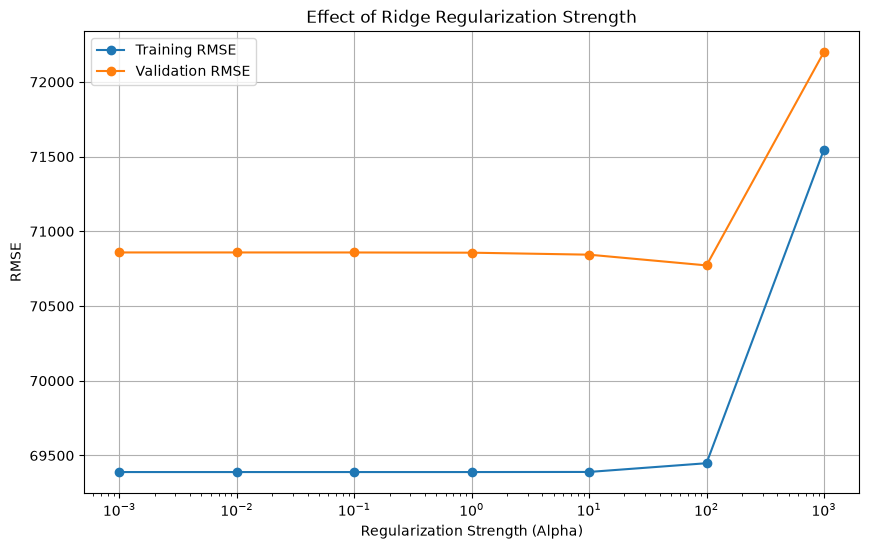

In [42]:
plt.figure(figsize=(10, 6))

plt.semilogx(
    ridge_results["Alpha"],
    ridge_results["Train_RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.semilogx(
    ridge_results["Alpha"],
    ridge_results["Validation_RMSE"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Regularization Strength (Alpha)")
plt.ylabel("RMSE")
plt.title("Effect of Ridge Regularization Strength")
plt.legend()
plt.grid(True)

plt.show()

### Plot for lasso

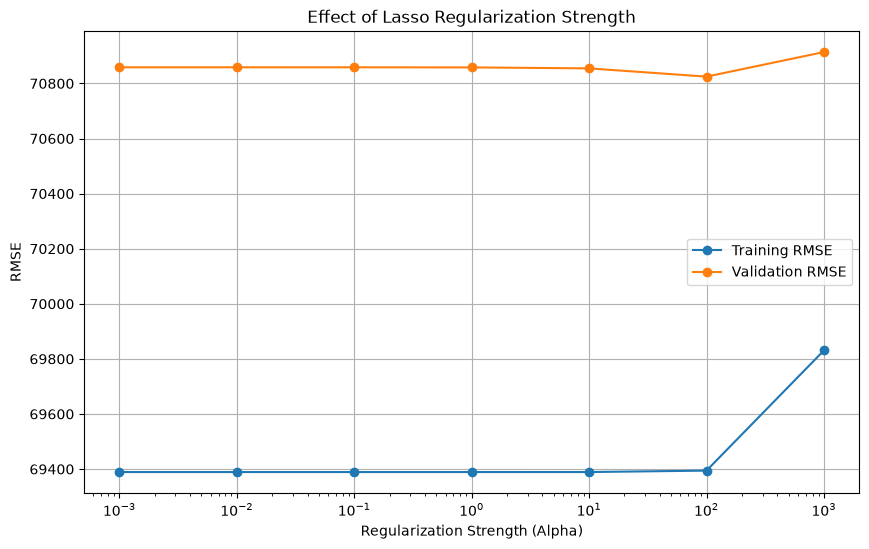

In [44]:
plt.figure(figsize=(10, 6))

plt.semilogx(
    lasso_results["Alpha"],
    lasso_results["Train_RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.semilogx(
    lasso_results["Alpha"],
    lasso_results["Validation_RMSE"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Regularization Strength (Alpha)")
plt.ylabel("RMSE")
plt.title("Effect of Lasso Regularization Strength")
plt.legend()
plt.grid(True)

plt.show()

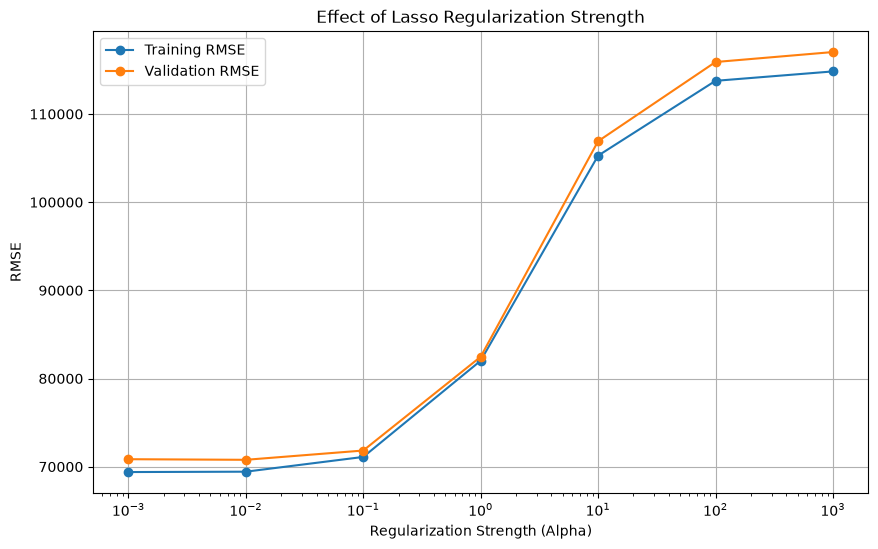

In [45]:
plt.figure(figsize=(10, 6))

plt.semilogx(
    elastic_net_results["Alpha"],
    elastic_net_results["Train_RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.semilogx(
    elastic_net_results["Alpha"],
    elastic_net_results["Validation_RMSE"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Regularization Strength (Alpha)")
plt.ylabel("RMSE")
plt.title("Effect of Lasso Regularization Strength")
plt.legend()
plt.grid(True)

plt.show()

## Hypothesis Result

**Hypothesis: Partially Supported**

The results partially support the hypothesis. Increasing regularization
strength generally reduced model flexibility, and excessive
regularization led to poorer validation performance, indicating
underfitting.

For Ridge and Lasso, moderate regularization produced small improvements
in validation performance, with the best results occurring around
\(\alpha=100\). However, the improvements over ordinary Linear
Regression were relatively small.

Elastic Net showed a stronger sensitivity to regularization strength.
Low values of \(\alpha\) produced performance close to Linear Regression,
while larger values substantially increased validation RMSE and reduced
\(R^2\), indicating underfitting.

Therefore, the results demonstrate that regularization strength must be
carefully selected. Regularization did not provide a substantial
improvement for the original linear model because the model was already
generalizing reasonably well.